# 02 — BAMIC wine multi-seed driver (Dr. Cao, Point 1)

Trains BAMIC on the wine dataset for **10 seeds (20260526–20260535)** using the
**official `01d_bamic_wine_gatefix_bestval.ipynb` code, unmodified except for
three audited patches**: the preregistered seed plan is extended to 10 seeds,
`RUN_SEED` is set per run, and `RUN_LABEL` is set to `'ms1'` so these runs land
in fresh folders and never touch the frozen paper run (`..._v1`).

Why this design instead of new training code: Codex reimplemented the pipeline
and its numbers therefore cannot be dropped into the paper. This driver `exec`s
the exact notebook code you already validated, so the multi-seed results are
by construction from the paper's pipeline. Each patch asserts it matched
exactly once — if the official notebook has drifted, the driver stops instead
of silently running something else.

**Per seed it additionally saves** (add-on block, appended after the official
cells): `test_prob_samples.npy` (100×10,000 posterior-predictive draws, needed
for the exact law-of-total-variance decomposition on the probability *and*
logit scales), `panel_word_uncertainty.csv` (word-level posterior summaries for
a fixed panel of the first 200 test documents — the token-level decomposition),
and `param_posterior_sd.csv` (fitted variational SDs vs their initialization).

**Resume-safe:** a seed whose output folder is already complete is skipped, so
you can run this notebook across several Colab sessions until the manifest at
the bottom shows 10/10. Expect roughly one full `01d` runtime per seed plus
~30% for the extra draws. GPU runtime required.

In [1]:

# ================================================================
# 0. Mount Drive and locate files. Notebooks stay on YOUR computer,
# same as your usual workflow: open this notebook in Colab from your
# local folder; only data/outputs live in Drive. If the official 01d
# notebook is needed and not already in this Colab session, a file
# picker opens so you can choose it from your local folder.
# If anything is guessed wrong, set NOTEBOOK_PATH and/or OUTPUTS_ROOT
# manually below and rerun this cell.
# ================================================================
import os
from pathlib import Path

REQUIRE_OFFICIAL_NB = True   # this notebook needs the 01d file itself

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('[note] not on Colab — set paths manually below.')

MYDRIVE = Path('/content/drive/MyDrive')
NOTEBOOK_PATH = None   # manual override, e.g. '/content/01d_bamic_wine_gatefix_bestval.ipynb'
OUTPUTS_ROOT = None    # manual override, e.g. '/content/drive/MyDrive/AMIC project/wine_benchmark/outputs'

OFFICIAL_NB = '01d_bamic_wine_gatefix_bestval.ipynb'
_PRUNE = {'drive', 'sample_data', '.config'}

def _walk_find(match, roots, max_depth=5, want_dir=False):
    """Bounded filename search, skipping hidden dirs and the Drive mount."""
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        base = str(root).rstrip('/').count('/')
        for dirpath, dirnames, filenames in os.walk(root):
            if dirpath.count('/') - base >= max_depth:
                dirnames[:] = []
                continue
            dirnames[:] = [d for d in dirnames
                           if not d.startswith('.') and d not in _PRUNE]
            names = dirnames if want_dir else filenames
            for n in names:
                if match(n):
                    return Path(dirpath) / n
    return None

if REQUIRE_OFFICIAL_NB and NOTEBOOK_PATH is None:
    # 1) already in this Colab session (drag-dropped into the Files panel,
    #    or uploaded on a previous run of this cell)
    for _cand in [Path('/content') / OFFICIAL_NB, Path.cwd() / OFFICIAL_NB]:
        if _cand.exists():
            NOTEBOOK_PATH = _cand
            break
    if NOTEBOOK_PATH is None:
        NOTEBOOK_PATH = _walk_find(lambda n: n == OFFICIAL_NB,
                                   [Path('/content')], max_depth=3)
    # 2) a copy kept in Drive (optional)
    if NOTEBOOK_PATH is None:
        _guess = MYDRIVE / 'AMIC project' / 'wine_benchmark' / OFFICIAL_NB
        NOTEBOOK_PATH = _guess if _guess.exists() else _walk_find(
            lambda n: n == OFFICIAL_NB, [MYDRIVE / 'AMIC project', MYDRIVE])
    # 3) pick it from your local computer (your normal upload workflow)
    if NOTEBOOK_PATH is None and ON_COLAB:
        print(f'{OFFICIAL_NB} is not in this session or Drive.')
        print('Choose it from your local folder, e.g. '
              'BAMIC_code/dr_cao_multiseed/ or '
              'BAMIC_code/BAMIC_codex_updated/wine_benchmark/:')
        from google.colab import files
        _up = files.upload()
        for _name in _up:
            if '01d_bamic_wine_gatefix_bestval' in _name and _name.endswith('.ipynb'):
                NOTEBOOK_PATH = Path('/content') / _name

if REQUIRE_OFFICIAL_NB:
    assert NOTEBOOK_PATH is not None and Path(NOTEBOOK_PATH).exists(), (
        f'Could not obtain {OFFICIAL_NB}. Rerun this cell and choose the file '
        f'in the upload dialog, or set NOTEBOOK_PATH manually above.')
    NOTEBOOK_PATH = str(NOTEBOOK_PATH)
    print('NOTEBOOK_PATH:', NOTEBOOK_PATH)

if OUTPUTS_ROOT is None:
    _guess = MYDRIVE / 'AMIC project' / 'wine_benchmark' / 'outputs'
    if _guess.exists() and any(_guess.glob('wine_bamic_*')):
        OUTPUTS_ROOT = _guess
    else:
        _hit = _walk_find(lambda n: n.startswith('wine_bamic_'),
                          [MYDRIVE / 'AMIC project', MYDRIVE], want_dir=True)
        OUTPUTS_ROOT = _hit.parent if _hit is not None else _guess
OUTPUTS_ROOT = Path(OUTPUTS_ROOT)
OUTPUTS_ROOT.mkdir(parents=True, exist_ok=True)
print('OUTPUTS_ROOT :', OUTPUTS_ROOT)
_existing = sorted(p.name for p in OUTPUTS_ROOT.glob('wine_bamic_*'))
print(f'existing wine_bamic_* run folders here: {len(_existing)}')
for _n in _existing[:8]:
    print('  ', _n)
if not _existing:
    print('  [check] none found — if runs exist elsewhere, set OUTPUTS_ROOT '
          'manually above. (For a first-ever run this is fine.)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NOTEBOOK_PATH: /content/drive/MyDrive/AMIC project/dr_cao_multiseed/01d_bamic_wine_gatefix_bestval.ipynb
OUTPUTS_ROOT : /content/drive/MyDrive/AMIC project/wine_benchmark/outputs
existing wine_bamic_* run folders here: 5
   wine_bamic_frozen_ep10_heads1_lamB0p1_lamS0p01_len100
   wine_bamic_frozen_ep15_heads1_lamB0p1_lamS0p01_len100
   wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_v1
   wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_unfrozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_v1
   wine_bamic_posenc_selnorm_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100


In [2]:
# ================================================================
# 1. Configuration — review before running
# ================================================================
SEEDS = [20260526, 20260527, 20260528, 20260529, 20260530,
         20260531, 20260532, 20260533, 20260534, 20260535]
MULTISEED_RUN_LABEL = 'ms1'   # keeps these runs separate from the frozen _v1 run

SAVE_TEST_DRAWS = True    # needed for the exact decomposition + seed-ensemble
RUN_TOKEN_PANEL = True    # token-level decomposition (fixed 200-doc panel)
PANEL_SIZE = 200
PANEL_MC = 100

REQUIRED = ['final_metrics.csv', 'test_document_uncertainty.csv',
            'example_word_uncertainty.csv', 'run_config.csv',
            'param_posterior_sd.csv']
if SAVE_TEST_DRAWS:
    REQUIRED.append('test_prob_samples.npy')
if RUN_TOKEN_PANEL:
    REQUIRED.append('panel_word_uncertainty.csv')
print('will require per seed:', REQUIRED)

will require per seed: ['final_metrics.csv', 'test_document_uncertainty.csv', 'example_word_uncertainty.csv', 'run_config.csv', 'param_posterior_sd.csv', 'test_prob_samples.npy', 'panel_word_uncertainty.csv']


In [3]:

# ================================================================
# Extraction + patch machinery.
# The official notebook is read from Drive and lightly patched.
# Every patch asserts it matched exactly the expected number of
# times, so any drift in the official notebook fails loudly here.
# ================================================================
import json, re, gc, hashlib, traceback
from pathlib import Path

def extract_code(nb_path):
    """Concatenate the official notebook's code cells, dropping magics."""
    raw = Path(nb_path).read_text()
    print('notebook sha256:', hashlib.sha256(raw.encode()).hexdigest()[:16])
    nb = json.loads(raw)
    chunks = []
    for cell in nb['cells']:
        if cell['cell_type'] != 'code':
            continue
        src = ''.join(cell['source'])
        lines = []
        for l in src.splitlines():
            if l.lstrip().startswith(('!', '%')):
                continue                      # shell/magic line
            m = re.match(r'^(\s*)(\w+)\s*=\s*!', l)
            if m:                             # shell capture, e.g. x = !nvidia-smi
                lines.append(f'{m.group(1)}{m.group(2)} = []  '
                             f'# shell capture stubbed by driver')
                continue
            lines.append(l)
        chunks.append('\n'.join(lines))
    return '\n\n# ===== CELL =====\n\n'.join(chunks)

def sub1(src, pattern, repl, expect=1, flags=0):
    out, n = re.subn(pattern, repl, src, flags=flags)
    assert n == expect, f'pattern {pattern!r} matched {n}x, expected {expect}'
    return out

def patch_seed_plan(src, seeds):
    plan = 'MATCHED_SEED_PLAN = [' + ', '.join(str(s) for s in seeds) + ']'
    return sub1(src, r'MATCHED_SEED_PLAN\s*=\s*\[[^\]]*\]', plan, flags=re.S)

def patch_run(src, seed, run_label):
    src = sub1(src, r'(?m)^RUN_SEED\s*=\s*\d+', f'RUN_SEED = {seed}')
    src = sub1(src, r"(?m)^RUN_LABEL\s*=\s*'[^']*'", f"RUN_LABEL = '{run_label}'")
    return src

def patch_prior(src, prior_sd):
    """Route both Bayesian heads' prior SD through one injected constant."""
    src = f'PRIOR_SD = {prior_sd}\n' + src
    src = sub1(src, r'prior_sigma_b=1\.0', 'prior_sigma_b=PRIOR_SD', expect=2)
    src = sub1(src, r'prior_sigma_beta=1\.0', 'prior_sigma_beta=PRIOR_SD', expect=2)
    return src

def find_run_folder(outputs_root, seed, run_label):
    hits = sorted(Path(outputs_root).glob(f'*seed{seed}_{run_label}'))
    assert len(hits) <= 1, f'multiple folders for seed {seed} {run_label}: {hits}'
    return hits[0] if hits else None

def folder_complete(folder, required):
    return folder is not None and all((folder / f).exists() for f in required)

def run_patched(source, tag, script_dir):
    """Save the patched script for provenance, then exec it fresh."""
    script_dir = Path(script_dir); script_dir.mkdir(parents=True, exist_ok=True)
    script_path = script_dir / f'seed_run_{tag}.py'
    script_path.write_text(source)
    print(f'--- executing {script_path.name} ({len(source)} chars) ---')
    ns = {'__name__': '__main__'}
    exec(compile(source, str(script_path), 'exec'), ns)
    return ns

def cleanup_after_run(ns):
    import matplotlib.pyplot as plt
    plt.close('all')
    ns.clear()
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


In [4]:
ADDON_TEMPLATE = r'''

# ================================================================
# MULTISEED ADD-ON (appended by the driver; not part of official 01d)
# Saves (a) the full matrix of test posterior-predictive draws,
# (b) word-level posterior summaries for a fixed panel of test
# documents, and (c) the fitted variational posterior SDs.
# All outputs go into the same OUTPUT_DIR as the official artifacts.
# ================================================================
import numpy as _np
import pandas as _pd
import torch as _torch
import torch.nn.functional as _F

SAVE_TEST_DRAWS = __SAVE_TEST_DRAWS__
RUN_TOKEN_PANEL = __RUN_TOKEN_PANEL__
PANEL_SIZE = __PANEL_SIZE__
PANEL_MC = __PANEL_MC__

if SAVE_TEST_DRAWS:
    # One extra posterior-predictive pass over the test loader, keeping
    # the raw [n_samples, n_docs] probability draws this time.
    _unc_addon, _prob_samples = posterior_predict_loader(
        model, test_loader, n_samples=FINAL_MC_SAMPLES)
    _np.save(OUTPUT_DIR / 'test_prob_samples.npy',
             _prob_samples.astype(_np.float32))
    _unc_addon.to_csv(OUTPUT_DIR / 'test_document_uncertainty_addon.csv',
                      index=False)
    print('addon: saved test_prob_samples.npy', _prob_samples.shape)

if RUN_TOKEN_PANEL:
    # Word-level posterior summaries for the first PANEL_SIZE test
    # documents (fixed panel, identical across seeds because the test
    # split is fixed on disk). Mirrors the section-17 example logic,
    # batched over documents.
    _n_panel = int(min(PANEL_SIZE, x_test.shape[0]))
    _ids = _torch.tensor(x_test[:_n_panel], dtype=_torch.long)
    _z_all = _np.zeros((PANEL_MC, _n_panel, MAX_LEN), dtype=_np.float32)
    _d_all = _np.zeros_like(_z_all)
    model.eval()
    with _torch.no_grad():
        for _s in range(PANEL_MC):
            for _start in range(0, _n_panel, BATCH_SIZE):
                _bb = _ids[_start:_start + BATCH_SIZE].to(DEVICE)
                _out = model(_bb, sample=True)
                _z_all[_s, _start:_start + _bb.shape[0]] = _out['word_logit'].cpu().numpy()
                _d_all[_s, _start:_start + _bb.shape[0]] = _out['delta'].cpu().numpy()
    _rows = []
    for _i in range(_n_panel):
        _L = int(len_test[_i])
        for _j in range(_L):
            _zs = _z_all[:, _i, _j]
            _ds = _d_all[:, _i, _j]
            _rows.append({
                'doc_index': _i,
                'position': _j,
                'word': id_to_word.get(int(x_test[_i, _j]), '<UNK>'),
                'y_true': int(test_df['y'].iloc[_i]),
                'z_mean': float(_zs.mean()),
                'z_sd': float(_zs.std()),
                'z_ci95_lo': float(_np.quantile(_zs, 0.025)),
                'z_ci95_hi': float(_np.quantile(_zs, 0.975)),
                'p_z_positive': float((_zs > 0).mean()),
                'delta_mean': float(_ds.mean()),
                'delta_sd': float(_ds.std()),
            })
    _pd.DataFrame(_rows).to_csv(OUTPUT_DIR / 'panel_word_uncertainty.csv',
                                index=False)
    print(f'addon: saved panel_word_uncertainty.csv '
          f'({_n_panel} docs, {len(_rows)} token rows)')

# Fitted variational posterior SDs of every BayesianLinear module,
# with the initialization value for comparison (init_rho = -5.0 gives
# softplus(-5) ~= 0.00672; posterior SDs that stay at this value have
# not moved from initialization).
_sd_rows = []
for _mod_name, _mod in model.named_modules():
    if _mod.__class__.__name__ == 'BayesianLinear':
        _w = _F.softplus(_mod.weight_rho).detach().cpu().numpy().ravel()
        _b = _F.softplus(_mod.bias_rho).detach().cpu().numpy().ravel()
        _all = _np.concatenate([_w, _b])
        _sd_rows.append({
            'module': _mod_name,
            'n_params': int(_all.size),
            'mean_posterior_sd': float(_all.mean()),
            'median_posterior_sd': float(_np.median(_all)),
            'min_posterior_sd': float(_all.min()),
            'max_posterior_sd': float(_all.max()),
            'init_sd_from_init_rho': float(_np.log1p(_np.exp(-5.0))),
            'prior_sigma': float(_mod.prior_sigma.item()),
        })
_pd.DataFrame(_sd_rows).to_csv(OUTPUT_DIR / 'param_posterior_sd.csv', index=False)
print('addon: saved param_posterior_sd.csv')
'''

def addon_source():
    return (ADDON_TEMPLATE
            .replace('__SAVE_TEST_DRAWS__', str(bool(SAVE_TEST_DRAWS)))
            .replace('__RUN_TOKEN_PANEL__', str(bool(RUN_TOKEN_PANEL)))
            .replace('__PANEL_SIZE__', str(PANEL_SIZE))
            .replace('__PANEL_MC__', str(PANEL_MC)))
print('addon length:', len(addon_source()), 'chars')

addon length: 4219 chars


notebook sha256: 86fa7bb32d48ee23

########## SEED 20260526 ##########
--- executing seed_run_20260526_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of available RAM
Using device: cuda
RUN_SEED: 20260526
MATCHED_SEED_PLAN: [20260526, 20260527, 20260528, 20260529, 20260530, 20260531, 20260532, 20260533, 20260534, 20260535]
RUN_MODE                : gate_calibrated_selnorm
RUN_SEED / RUN_LABEL    : 20260526 / ms1
FREEZE_EMBEDDINGS       : True
ABLATION_EPOCHS         : 15
NUM_HEADS               : 1
LAMBDA_BOILERPLATE      : 0.1
LAMBDA_STOPWORD         : 0.01
STOPWORD_WARMUP_EPOCHS  : 2
BAMIC_LEARNING_RATE     : 0.0003
MAX_LEN / BATCH_SIZE    : 100 / 128
POSITION_ENCODING       : learned_absolute | enabled: True
AGGREGATION_MODE        : selected_token_mean
LAMBDA_P1 / P2 / P3     : 0.01 / 0.0 / 0.001
SELECTION_RATE_BAND     : (0.075, 0.125) | lambda: 1.0 | enabled: True
GATE CHECKPOINT         : True | mean-rate envelope: (0.05, 0.15) | max low/high document fractions: (0.1

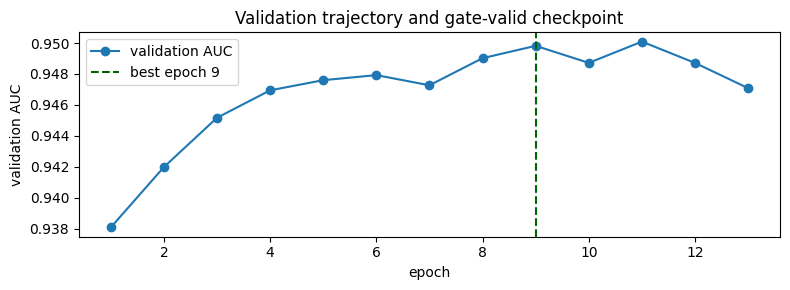

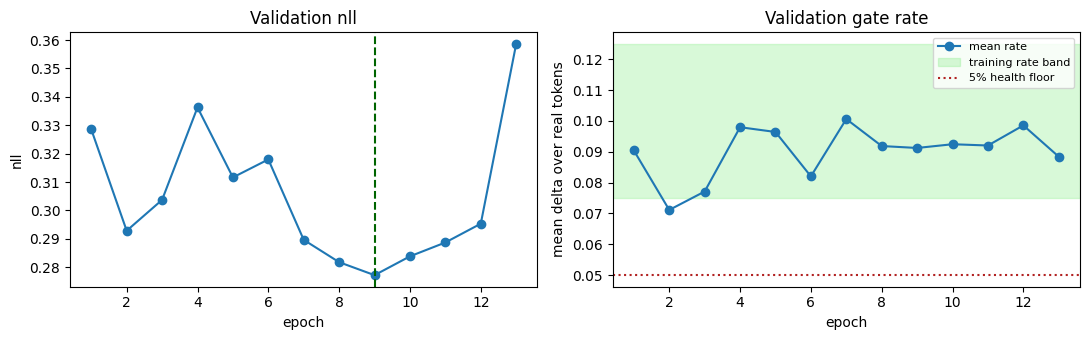

Restored epoch 9: validation nll=0.277218
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,2.987437,0.091607,0.069042,0.089755,0.120178,0.033158,2.987438,0.550270,0.0006,0.1250,0.03384
1,valid,2.986299,0.091462,0.070048,0.089716,0.119454,0.051267,2.986300,0.675858,0.0000,0.1180,0.03300
2,test,2.983014,0.091584,0.069168,0.089728,0.120026,0.040724,2.983015,0.713337,0.0009,0.1249,0.03190


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,2.978432,0.091330,0.068857,0.089482,0.119974,0.0006,0.004720,2.978433,0.550786,...,0.365087,0.001365,0.301460,2.629568,3.198137,0.190364,25000,True,eligible,False
1,valid,2.979261,0.091250,0.069795,0.089453,0.119561,0.0000,0.003667,2.979262,0.666440,...,0.366570,0.001344,0.300868,2.641073,3.193569,0.190284,3000,True,eligible,True
2,test,2.972073,0.091247,0.068860,0.089368,0.119661,0.0009,0.004400,2.972074,0.700344,...,0.363305,0.001250,0.300559,2.632560,3.201088,0.190328,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.53
Best validation-F1 threshold      : 0.455
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


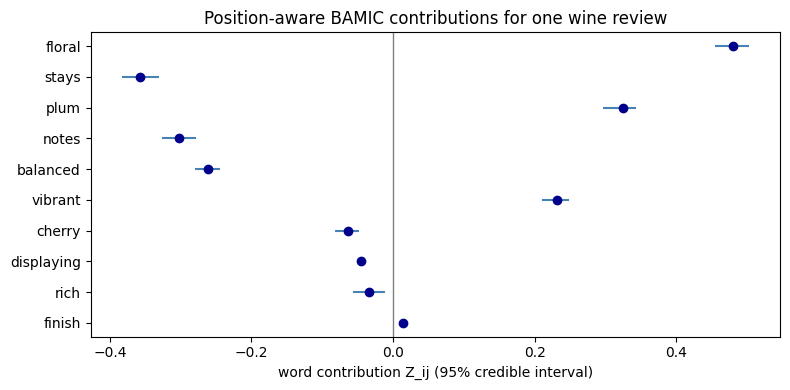

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.893, 'f1': 0.8487, 'auc': np.float64(0.9617), 'brier': np.float64(0.0756), 'nll': 0.242} ece= 0.0267
valid {'acc': 0.875, 'f1': 0.8227, 'auc': np.float64(0.9498), 'brier': np.float64(0.0879), 'nll': 0.2772} ece= 0.0292
test {'acc': 0.8749, 'f1': 0.8243, 'auc': np.float64(0.9505), 'brier': np.float64(0.0869), 'nll': 0.2757} ece= 0.0278
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260526

########## SEED 20260527 ##########
--- executing seed_run_20260527_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of available

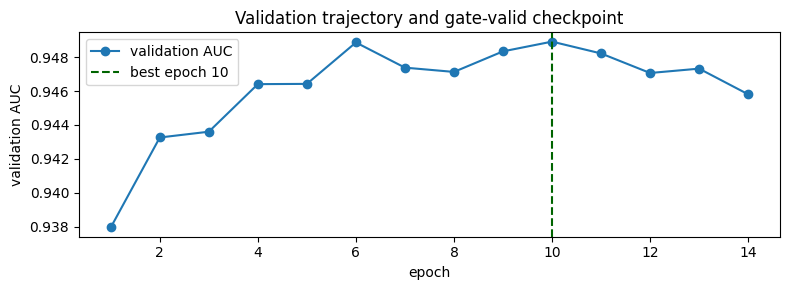

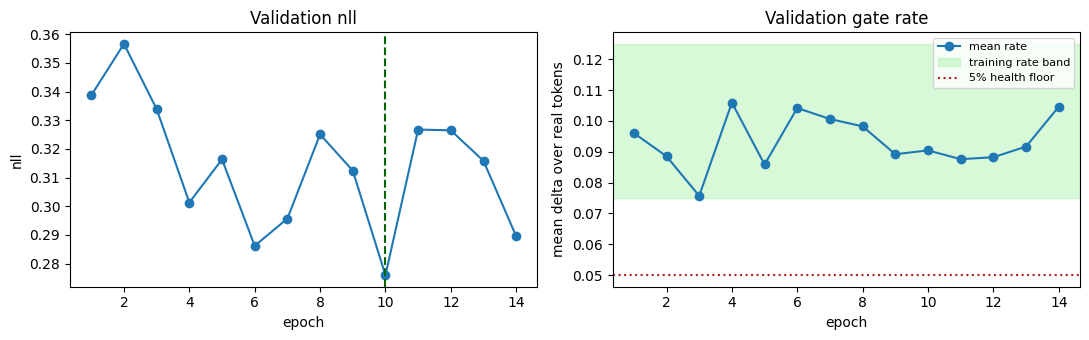

Restored epoch 10: validation nll=0.275944
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,2.953748,0.090636,0.067664,0.090428,0.114501,0.015260,2.953749,0.137338,0.0026,0.131360,0.01312
1,valid,2.957236,0.090727,0.067999,0.090523,0.114633,0.038836,2.957237,0.746592,0.0040,0.135333,0.01200
2,test,2.937805,0.090317,0.067361,0.090078,0.114521,0.037492,2.937806,0.632718,0.0027,0.139100,0.01200


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,2.941061,0.090249,0.067338,0.090011,0.113938,0.0026,0.000720,2.941062,0.136481,...,0.257164,0.000217,0.223812,2.000831,2.409346,0.122885,25000,True,eligible,False
1,valid,2.948566,0.090466,0.067641,0.090230,0.114623,0.0040,0.000333,2.948567,0.743238,...,0.257457,0.000153,0.223388,2.016841,2.404944,0.122788,3000,True,eligible,True
2,test,2.927067,0.089988,0.067034,0.089795,0.114022,0.0026,0.000900,2.927068,0.632083,...,0.257076,0.000181,0.223190,1.994404,2.419876,0.122702,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.545
Best validation-F1 threshold      : 0.505
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


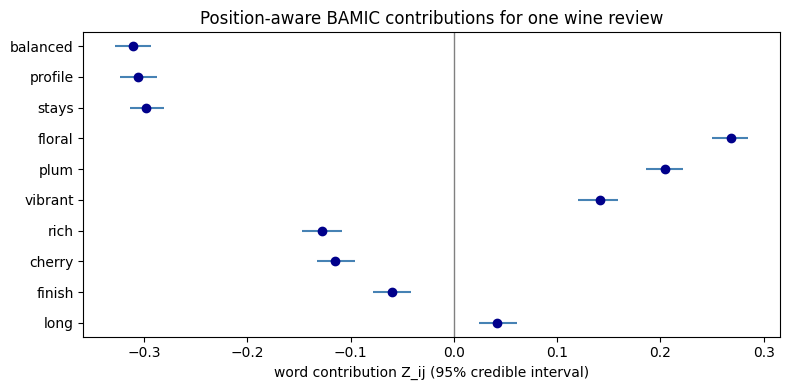

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.893, 'f1': 0.8456, 'auc': np.float64(0.9604), 'brier': np.float64(0.0759), 'nll': 0.2431} ece= 0.0155
valid {'acc': 0.8817, 'f1': 0.8302, 'auc': np.float64(0.9489), 'brier': np.float64(0.0869), 'nll': 0.2758} ece= 0.0219
test {'acc': 0.8762, 'f1': 0.8225, 'auc': np.float64(0.9489), 'brier': np.float64(0.0868), 'nll': 0.276} ece= 0.0192
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260527_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260527

########## SEED 20260528 ##########
--- executing seed_run_20260528_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of availabl

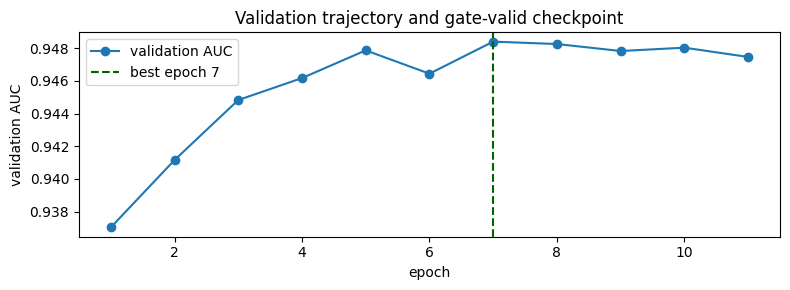

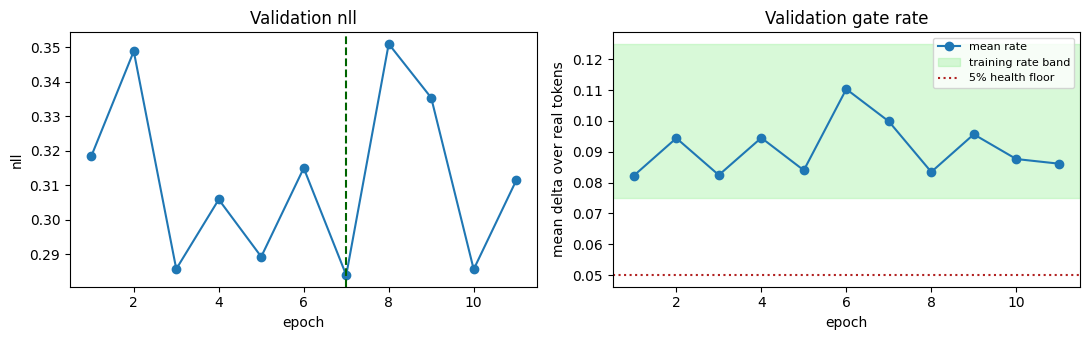

Restored epoch 7: validation nll=0.283966
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,3.257855,0.100053,0.082438,0.099588,0.119199,0.056896,3.257856,0.537835,0.0,0.010160,0.02108
1,valid,3.271088,0.100335,0.083479,0.099791,0.119189,0.063252,3.271089,1.014779,0.0,0.006333,0.02100
2,test,3.252368,0.099999,0.082703,0.099571,0.119110,0.055643,3.252369,0.775024,0.0,0.009200,0.01770


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,3.249719,0.099807,0.082270,0.099309,0.118769,0.0,0.000640,3.249720,0.537334,...,0.293570,0.000028,0.264559,2.208120,2.616819,0.160564,25000,True,eligible,False
1,valid,3.255983,0.099877,0.083080,0.099424,0.118484,0.0,0.001333,3.255984,0.998376,...,0.292269,0.000051,0.265087,2.224870,2.621234,0.160458,3000,True,eligible,True
2,test,3.240461,0.099635,0.082247,0.099216,0.118615,0.0,0.000800,3.240462,0.766245,...,0.292295,0.000018,0.264468,2.213509,2.617230,0.160475,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.635
Best validation-F1 threshold      : 0.44
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


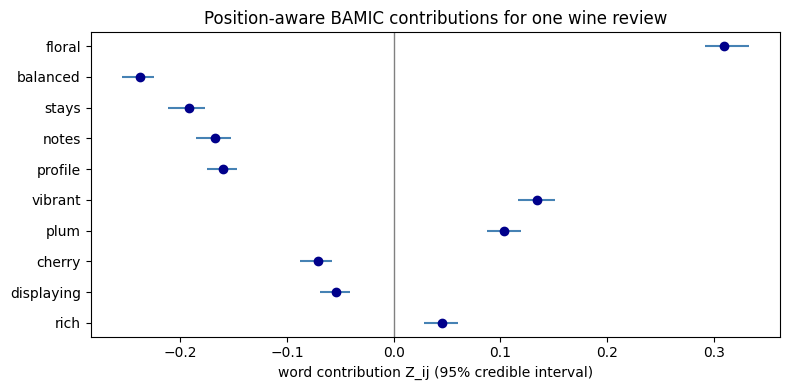

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8832, 'f1': 0.8389, 'auc': np.float64(0.9572), 'brier': np.float64(0.0821), 'nll': 0.2621} ece= 0.0437
valid {'acc': 0.8707, 'f1': 0.8202, 'auc': np.float64(0.9484), 'brier': np.float64(0.0903), 'nll': 0.2839} ece= 0.0402
test {'acc': 0.871, 'f1': 0.8224, 'auc': np.float64(0.9497), 'brier': np.float64(0.0885), 'nll': 0.2801} ece= 0.0401
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260528_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260528

########## SEED 20260529 ##########
--- executing seed_run_20260529_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of availab

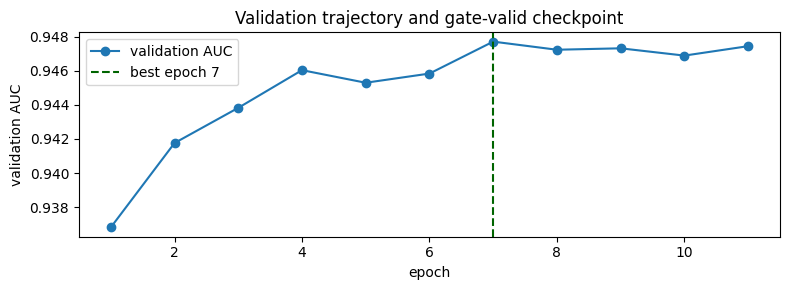

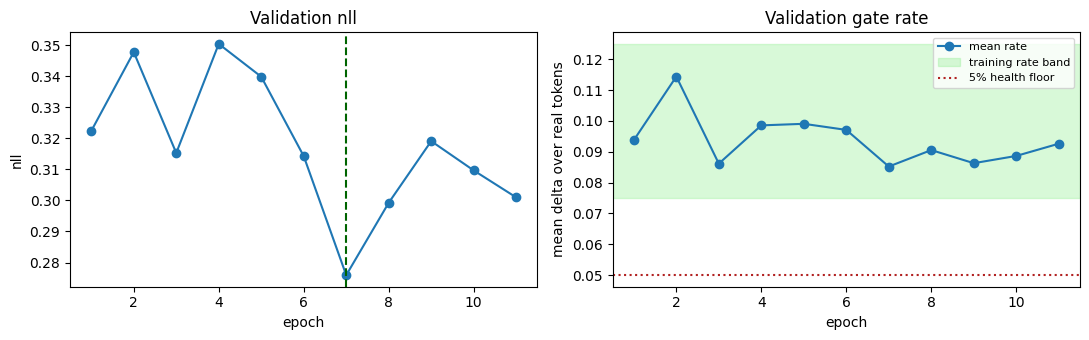

Restored epoch 7: validation nll=0.275936
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,2.773060,0.085099,0.063806,0.085029,0.107035,0.027583,2.773061,0.360643,0.00452,0.22332,0.002400
1,valid,2.785869,0.085412,0.064277,0.085355,0.106334,0.041544,2.785871,0.688588,0.00200,0.21500,0.003667
2,test,2.760483,0.084854,0.062891,0.084753,0.107264,0.029165,2.760484,0.436443,0.00600,0.22640,0.003300


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,2.761373,0.084742,0.063536,0.084694,0.106584,0.004840,0.0,2.761373,0.35468,...,0.216651,0.000013,0.189646,1.860305,2.218102,0.101086,25000,True,eligible,False
1,valid,2.779812,0.085225,0.064083,0.085221,0.106175,0.001667,0.0,2.779813,0.69067,...,0.217623,0.000020,0.190541,1.858045,2.212773,0.101402,3000,True,eligible,True
2,test,2.751296,0.084570,0.062659,0.084524,0.106935,0.006200,0.0,2.751297,0.43070,...,0.217374,0.000009,0.189678,1.861554,2.225384,0.101412,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.46
Best validation-F1 threshold      : 0.46
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


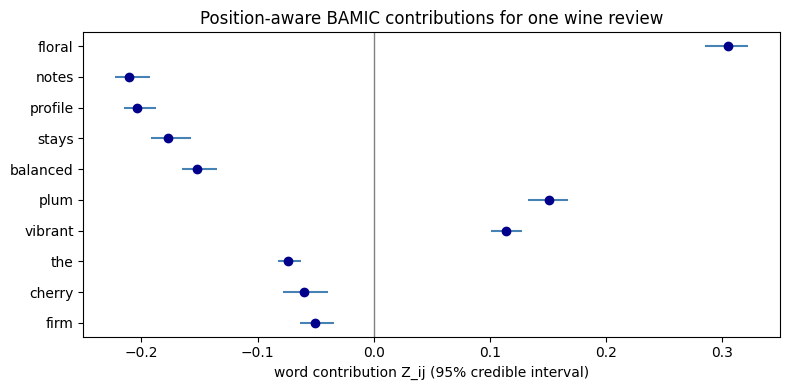

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8861, 'f1': 0.8328, 'auc': np.float64(0.9564), 'brier': np.float64(0.0795), 'nll': 0.2549} ece= 0.0142
valid {'acc': 0.8753, 'f1': 0.8165, 'auc': np.float64(0.9477), 'brier': np.float64(0.087), 'nll': 0.276} ece= 0.0125
test {'acc': 0.8782, 'f1': 0.8213, 'auc': np.float64(0.9494), 'brier': np.float64(0.0855), 'nll': 0.2719} ece= 0.0077
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260529_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260529

########## SEED 20260530 ##########
--- executing seed_run_20260530_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of availabl

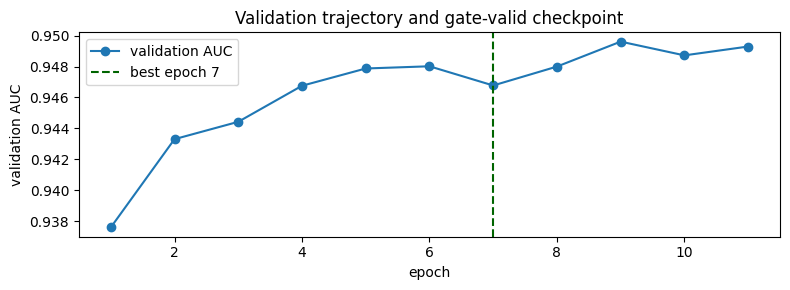

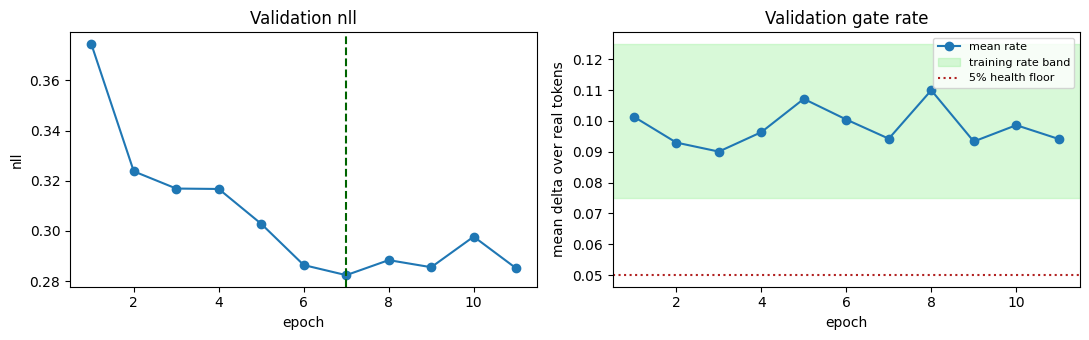

Restored epoch 7: validation nll=0.282391
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,3.087146,0.094620,0.072695,0.094368,0.117065,0.035441,3.087147,0.373825,0.000920,0.070640,0.0180
1,valid,3.088529,0.094661,0.073305,0.094561,0.116365,0.043269,3.088530,0.649040,0.000333,0.068667,0.0200
2,test,3.085926,0.094757,0.072385,0.094375,0.117467,0.042813,3.085927,0.690003,0.000800,0.074400,0.0193


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,3.075024,0.094252,0.072336,0.094008,0.116611,0.001000,0.002160,3.075025,0.372253,...,0.233763,0.000391,0.207241,1.797254,2.129087,0.103199,25000,True,eligible,False
1,valid,3.075318,0.094260,0.073202,0.094156,0.115804,0.000333,0.001333,3.075319,0.653148,...,0.231267,0.000275,0.205969,1.805352,2.121642,0.102406,3000,True,eligible,True
2,test,3.070921,0.094296,0.072118,0.093891,0.116864,0.000800,0.003600,3.070922,0.693365,...,0.233764,0.000505,0.208273,1.792772,2.125887,0.103168,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.585
Best validation-F1 threshold      : 0.48
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


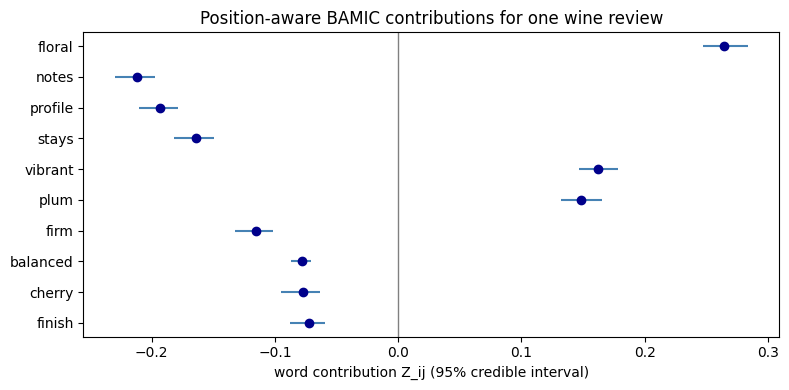

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8844, 'f1': 0.8363, 'auc': np.float64(0.9559), 'brier': np.float64(0.0813), 'nll': 0.2594} ece= 0.0289
valid {'acc': 0.874, 'f1': 0.8209, 'auc': np.float64(0.9467), 'brier': np.float64(0.0898), 'nll': 0.2824} ece= 0.0267
test {'acc': 0.8737, 'f1': 0.8221, 'auc': np.float64(0.9488), 'brier': np.float64(0.0874), 'nll': 0.277} ece= 0.0252
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260530_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260530

########## SEED 20260531 ##########
--- executing seed_run_20260531_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of availabl

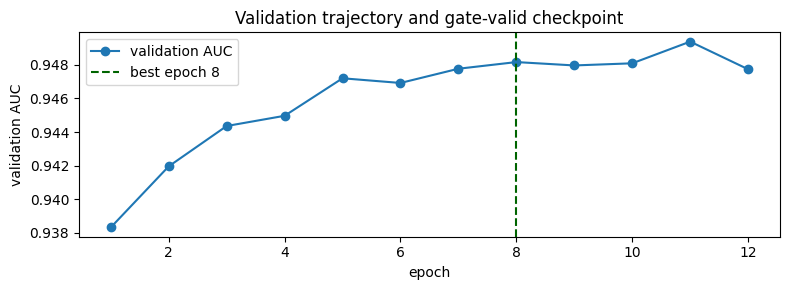

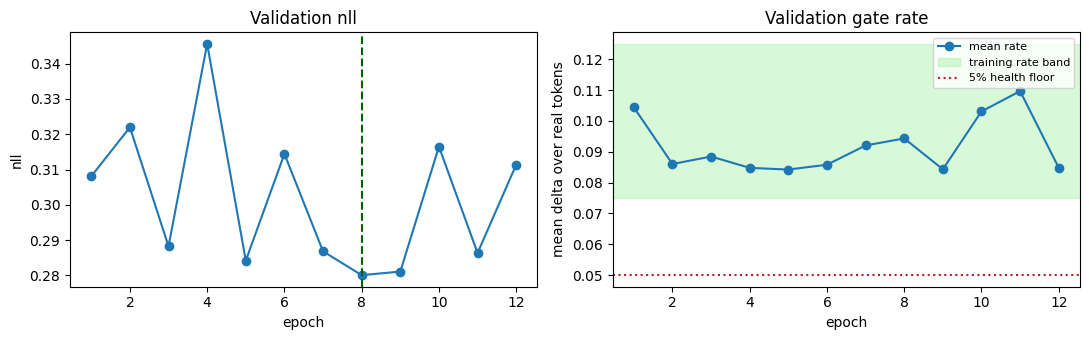

Restored epoch 8: validation nll=0.280092
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,3.095453,0.094766,0.078101,0.093729,0.115415,0.050771,3.095453,0.638474,0.0000,0.0244,0.016720
1,valid,3.097363,0.094692,0.078032,0.093500,0.116208,0.051231,3.097364,0.871320,0.0000,0.0220,0.018333
2,test,3.084728,0.094574,0.078328,0.093427,0.114818,0.048645,3.084728,0.681036,0.0001,0.0229,0.015500


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,3.080636,0.094315,0.077721,0.093254,0.114949,0.0000,0.00084,3.080637,0.628282,...,0.325244,0.001829,0.292978,2.293336,2.848276,0.167499,25000,True,eligible,False
1,valid,3.085858,0.094339,0.077933,0.093111,0.115585,0.0000,0.00100,3.085859,0.866663,...,0.326727,0.001883,0.292153,2.293646,2.844509,0.166985,3000,True,eligible,True
2,test,3.072838,0.094212,0.078098,0.093058,0.114481,0.0001,0.00130,3.072839,0.676326,...,0.324573,0.001923,0.292310,2.296105,2.843126,0.167303,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.565
Best validation-F1 threshold      : 0.44
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


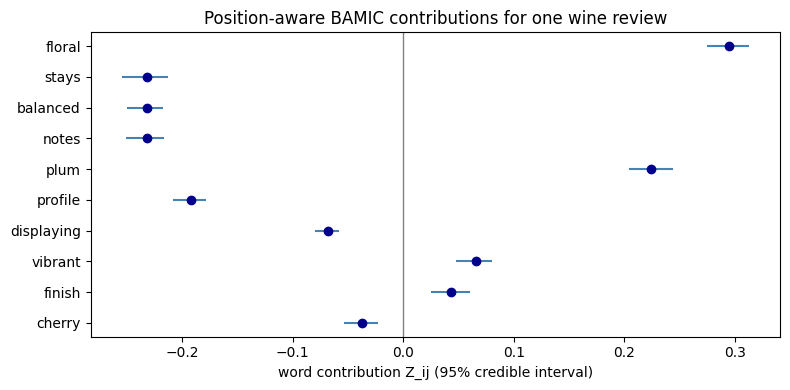

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8892, 'f1': 0.8435, 'auc': np.float64(0.9585), 'brier': np.float64(0.079), 'nll': 0.2527} ece= 0.0302
valid {'acc': 0.8733, 'f1': 0.8211, 'auc': np.float64(0.9481), 'brier': np.float64(0.0891), 'nll': 0.2802} ece= 0.0295
test {'acc': 0.8769, 'f1': 0.8269, 'auc': np.float64(0.9506), 'brier': np.float64(0.0861), 'nll': 0.2732} ece= 0.0283
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260531_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260531

########## SEED 20260532 ##########
--- executing seed_run_20260532_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of availab

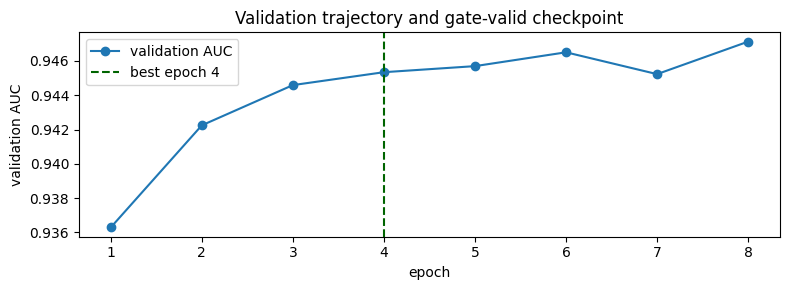

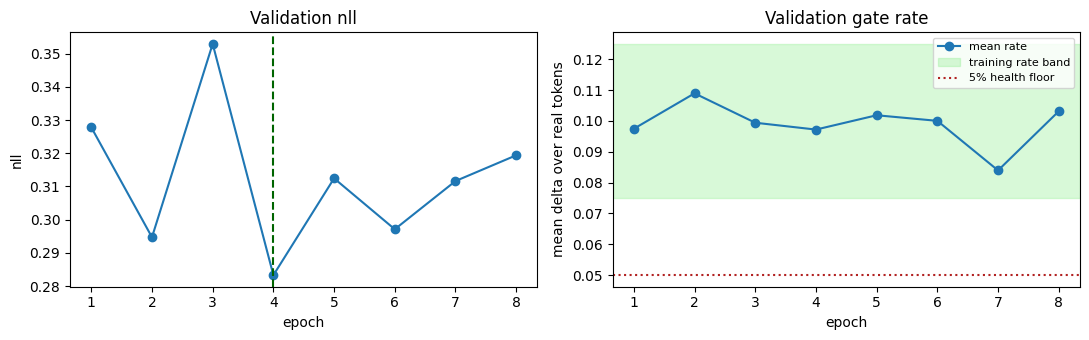

Restored epoch 4: validation nll=0.283301
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,3.188899,0.097381,0.079140,0.097743,0.114358,0.034357,3.188901,0.309215,0.0002,0.02544,0.0070
1,valid,3.188858,0.097330,0.080020,0.097670,0.113474,0.053384,3.188859,0.722615,0.0000,0.01800,0.0070
2,test,3.181470,0.097293,0.078672,0.097549,0.114582,0.036214,3.181471,0.362144,0.0004,0.02640,0.0062


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,3.175724,0.096981,0.078892,0.097350,0.113830,0.0002,0.00008,3.175725,0.300084,...,0.188557,0.0,0.177399,1.596819,1.816001,0.078742,25000,True,eligible,False
1,valid,3.184976,0.097214,0.079720,0.097596,0.113345,0.0000,0.00000,3.184977,0.714971,...,0.187910,0.0,0.177147,1.597593,1.810838,0.078352,3000,True,eligible,True
2,test,3.169032,0.096918,0.078547,0.097142,0.114113,0.0004,0.00010,3.169033,0.357188,...,0.188645,0.0,0.177492,1.595832,1.817176,0.078754,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.63
Best validation-F1 threshold      : 0.355
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


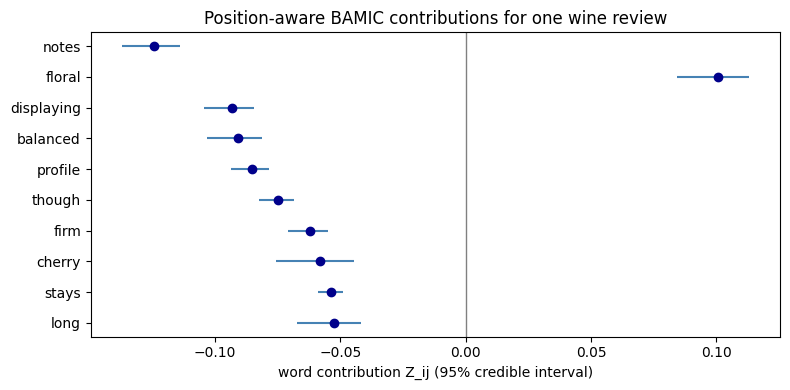

Stopword contamination in top-100 corpus words: 1
train {'acc': 0.8794, 'f1': 0.8221, 'auc': np.float64(0.9506), 'brier': np.float64(0.0847), 'nll': 0.2689} ece= 0.0093
valid {'acc': 0.8707, 'f1': 0.8092, 'auc': np.float64(0.9453), 'brier': np.float64(0.0896), 'nll': 0.2833} ece= 0.0194
test {'acc': 0.8775, 'f1': 0.82, 'auc': np.float64(0.9474), 'brier': np.float64(0.0876), 'nll': 0.2777} ece= 0.0127
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260532_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260532

########## SEED 20260533 ##########
--- executing seed_run_20260533_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of availabl

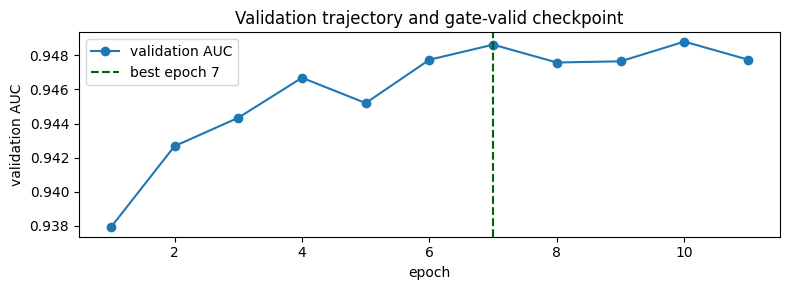

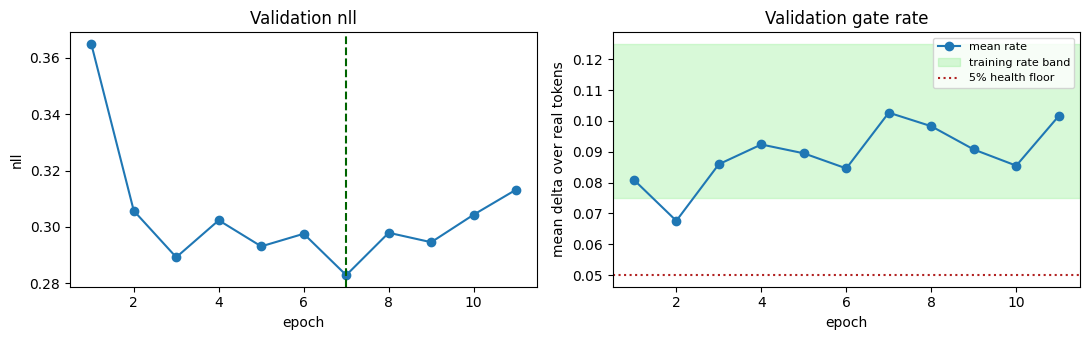

Restored epoch 7: validation nll=0.282938
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,3.373492,0.103052,0.088164,0.102876,0.118178,0.056568,3.373493,0.558509,0.0,0.002000,0.01304
1,valid,3.378332,0.103072,0.088670,0.102886,0.118318,0.066818,3.378333,0.954315,0.0,0.001333,0.01400
2,test,3.367983,0.102963,0.088066,0.102876,0.117668,0.056595,3.367984,0.691751,0.0,0.001100,0.01110


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,3.362985,0.102735,0.088020,0.102573,0.117741,0.0,0.000120,3.362986,0.549242,...,0.260085,0.000057,0.237989,1.977314,2.262419,0.128826,25000,True,eligible,False
1,valid,3.366071,0.102702,0.088609,0.102479,0.117825,0.0,0.000333,3.366072,0.952983,...,0.259158,0.000031,0.237364,1.984087,2.259878,0.128706,3000,True,eligible,True
2,test,3.354487,0.102550,0.087909,0.102487,0.117074,0.0,0.000100,3.354488,0.693658,...,0.258926,0.000031,0.237121,1.978576,2.261928,0.128850,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.625
Best validation-F1 threshold      : 0.49
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


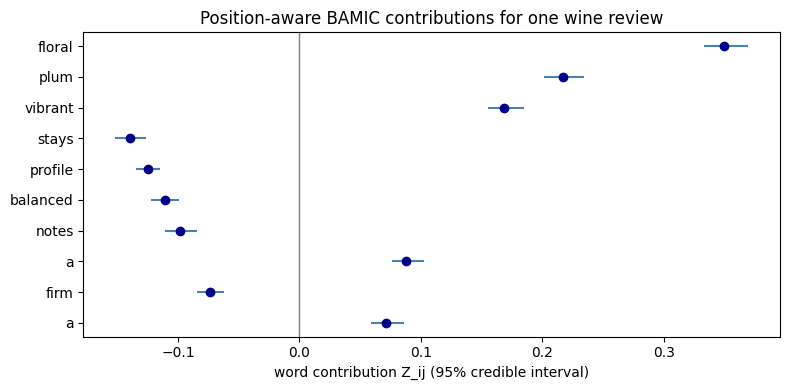

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.886, 'f1': 0.8399, 'auc': np.float64(0.9567), 'brier': np.float64(0.0815), 'nll': 0.2608} ece= 0.0375
valid {'acc': 0.8747, 'f1': 0.824, 'auc': np.float64(0.9486), 'brier': np.float64(0.0896), 'nll': 0.283} ece= 0.0377
test {'acc': 0.8736, 'f1': 0.8232, 'auc': np.float64(0.9494), 'brier': np.float64(0.0883), 'nll': 0.2811} ece= 0.0375
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260533_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260533

########## SEED 20260534 ##########
--- executing seed_run_20260534_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of available

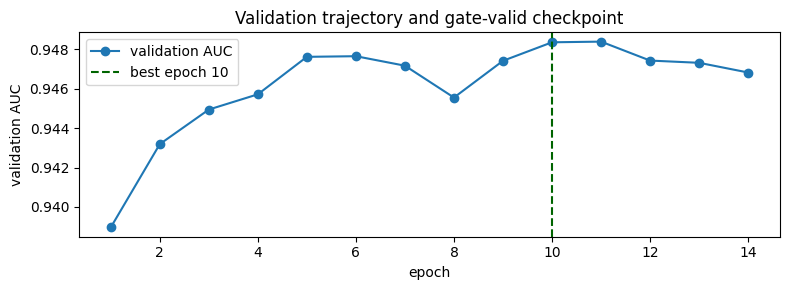

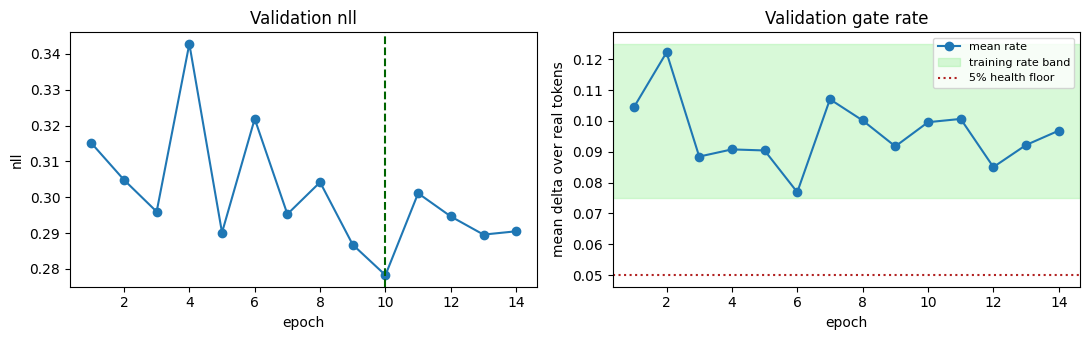

Restored epoch 10: validation nll=0.278273
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,3.260602,0.100150,0.075900,0.100144,0.124368,0.030976,3.260603,0.346070,0.000840,0.045160,0.046880
1,valid,3.267234,0.100309,0.075687,0.100372,0.123578,0.042705,3.267235,0.868938,0.000667,0.044333,0.042667
2,test,3.245844,0.099845,0.075300,0.099963,0.124606,0.040376,3.245845,0.788450,0.001100,0.047900,0.046700


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,3.250457,0.099838,0.075664,0.099776,0.123979,0.000800,0.001080,3.250458,0.340592,...,0.287157,0.0,0.247971,2.012612,2.448551,0.139074,25000,True,eligible,False
1,valid,3.244241,0.099609,0.075048,0.099659,0.122694,0.000667,0.001667,3.244242,0.862647,...,0.283210,0.0,0.246530,2.023608,2.445113,0.138971,3000,True,eligible,True
2,test,3.236408,0.099555,0.075163,0.099525,0.124031,0.001100,0.000900,3.236409,0.784391,...,0.286505,0.0,0.248030,2.015096,2.452796,0.139336,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.445
Best validation-F1 threshold      : 0.445
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


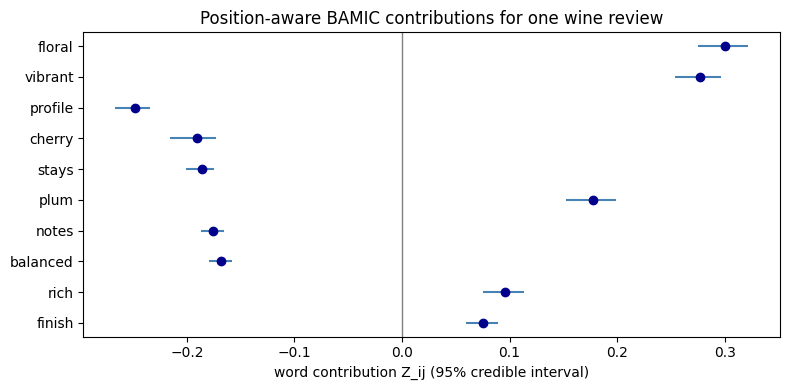

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8924, 'f1': 0.8468, 'auc': np.float64(0.961), 'brier': np.float64(0.076), 'nll': 0.2424} ece= 0.022
valid {'acc': 0.8733, 'f1': 0.8194, 'auc': np.float64(0.9484), 'brier': np.float64(0.0882), 'nll': 0.2783} ece= 0.0306
test {'acc': 0.8758, 'f1': 0.8239, 'auc': np.float64(0.9497), 'brier': np.float64(0.0866), 'nll': 0.2745} ece= 0.0227
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260534_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260534

########## SEED 20260535 ##########
--- executing seed_run_20260535_ms1.py (93736 chars) ---

Your runtime has 179.4 gigabytes of available

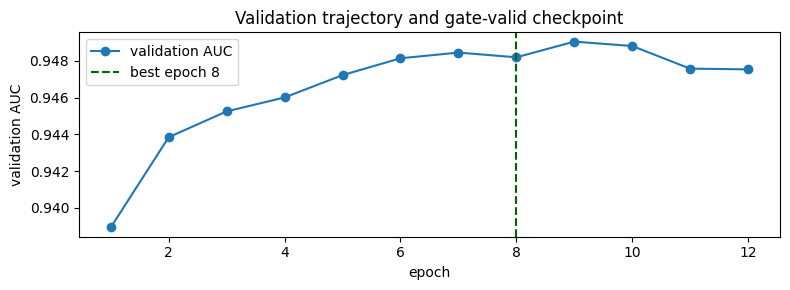

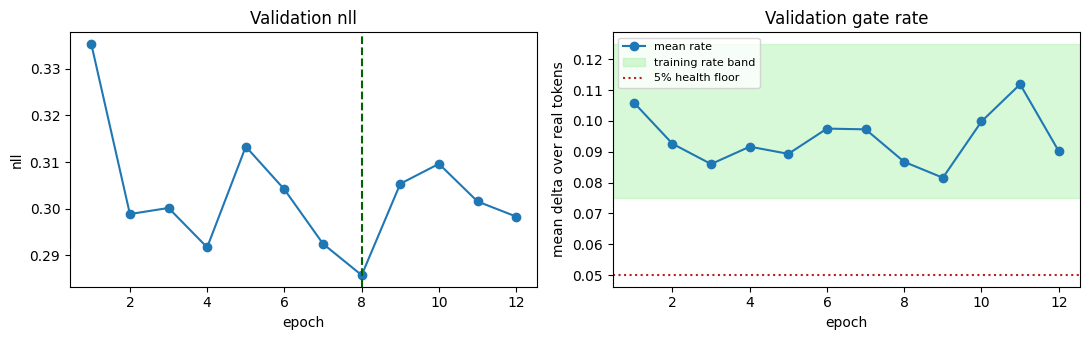

Restored epoch 8: validation nll=0.285764
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,2.844712,0.087258,0.063626,0.086546,0.111776,0.027391,2.844712,0.398558,0.00488,0.20064,0.015400
1,valid,2.842664,0.087207,0.064062,0.086635,0.111365,0.040697,2.842664,0.667275,0.00300,0.18300,0.013667
2,test,2.839622,0.087312,0.063420,0.086675,0.112037,0.032755,2.839623,0.508424,0.00560,0.20360,0.017600


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,2.830145,0.086813,0.063273,0.086089,0.111249,0.005240,0.00516,2.830146,0.391810,...,0.257781,0.001413,0.229652,2.001329,2.473245,0.122172,25000,True,eligible,False
1,valid,2.827543,0.086741,0.063541,0.086105,0.110695,0.002667,0.00400,2.827544,0.661748,...,0.255202,0.001150,0.227697,2.000649,2.462759,0.122003,3000,True,eligible,True
2,test,2.827158,0.086932,0.062958,0.086242,0.111480,0.005700,0.00470,2.827159,0.500691,...,0.260709,0.001449,0.231458,2.010550,2.473941,0.122087,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.7
Best validation-F1 threshold      : 0.48
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


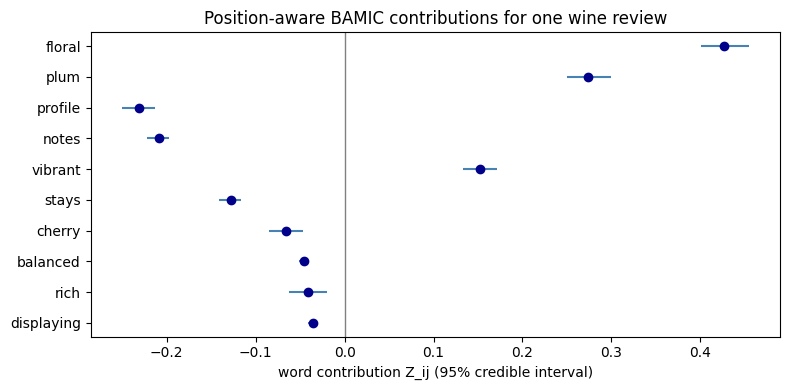

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8858, 'f1': 0.8412, 'auc': np.float64(0.9586), 'brier': np.float64(0.0801), 'nll': 0.2549} ece= 0.0366
valid {'acc': 0.8733, 'f1': 0.8229, 'auc': np.float64(0.9482), 'brier': np.float64(0.0906), 'nll': 0.2856} ece= 0.0365
test {'acc': 0.8729, 'f1': 0.8239, 'auc': np.float64(0.95), 'brier': np.float64(0.0888), 'nll': 0.2806} ece= 0.0369
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260535_ms1
addon: saved test_prob_samples.npy (100, 10000)
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] seed 20260535


In [5]:
# ================================================================
# 2. Run loop — skips complete seeds, stops on the first failure
# ================================================================
base_source = extract_code(NOTEBOOK_PATH)
script_dir = Path(OUTPUTS_ROOT) / '_multiseed_driver_scripts'

for seed in SEEDS:
    folder = find_run_folder(OUTPUTS_ROOT, seed, MULTISEED_RUN_LABEL)
    if folder_complete(folder, REQUIRED):
        print(f'[skip] seed {seed}: complete at {folder.name}')
        continue
    if folder is not None:
        print(f'[WARN] seed {seed}: folder {folder.name} exists but is '
              f'INCOMPLETE. The official notebook refuses non-empty folders. '
              f'Move it aside in Drive (e.g. rename with _broken) and rerun. '
              f'Skipping for now.')
        continue
    src = patch_seed_plan(base_source, SEEDS)
    src = patch_run(src, seed, MULTISEED_RUN_LABEL)
    src = src + addon_source()
    print(f'\n########## SEED {seed} ##########')
    try:
        ns = run_patched(src, f'{seed}_{MULTISEED_RUN_LABEL}', script_dir)
    except Exception:
        traceback.print_exc()
        print(f'[STOP] seed {seed} failed — fix before continuing so later '
              f'seeds are not trained under a broken state.')
        break
    cleanup_after_run(ns)
    print(f'[done] seed {seed}')

In [6]:
# ================================================================
# 3. Completeness manifest — rerun this notebook until 10/10 complete
# ================================================================
import pandas as pd
rows = []
for seed in SEEDS:
    folder = find_run_folder(OUTPUTS_ROOT, seed, MULTISEED_RUN_LABEL)
    row = {'seed': seed,
           'folder': folder.name if folder else '(missing)',
           'complete': folder_complete(folder, REQUIRED)}
    if folder is not None and (folder / 'final_metrics.csv').exists():
        fm = pd.read_csv(folder / 'final_metrics.csv')
        test = fm[fm['split'] == 'test']
        if len(test):
            row['test_acc'] = round(float(test['acc'].iloc[0]), 4)
            row['test_nll'] = round(float(test['nll'].iloc[0]), 4)
            row['best_epoch'] = int(test['best_epoch'].iloc[0])
    rows.append(row)
manifest = pd.DataFrame(rows)
print(manifest.to_string(index=False))
n_done = int(manifest['complete'].sum())
print(f'\n{n_done}/{len(SEEDS)} seeds complete.')
if n_done == len(SEEDS):
    print('All done — proceed to 03_bamic_wine_multiseed_analysis.ipynb')

    seed                                                                                                                           folder  complete  test_acc  test_nll  best_epoch
20260526 wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_ms1      True    0.8749    0.2757           9
20260527 wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260527_ms1      True    0.8762    0.2760          10
20260528 wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260528_ms1      True    0.8710    0.2801           7
20260529 wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260529_ms1      True    0.8782    0.2719           7
20260530 wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lam

## Notes

- **Gate-health failures:** if a seed fails the gate-valid checkpoint screen,
  do not tune anything. Keep the folder, note the seed, and report it — that is
  itself a stability datum for the paper.
- **Protocol difference vs the matched-seed plan:** the original protocol ran
  one seed per fresh runtime. This driver re-seeds every RNG at the start of
  each run, so RNG state is identical either way; the only residual difference
  is nondeterministic GPU kernel scheduling, which fresh runtimes do not remove
  either. If you prefer the strict protocol, run one seed per session by
  shortening `SEEDS` to a single value each time — everything else is
  unchanged.
- Seed 20260526 is retrained here (as `_ms1`) rather than reusing the frozen
  `_v1` folder, so all 10 runs carry the add-on outputs under an identical
  protocol. The frozen paper run is never touched; the analysis notebook
  additionally compares `20260526_ms1` against the frozen `_v1` as a
  same-seed reproducibility check.